In [ ]:
import random
SEED = 42

BENCHMARKS = ["gsm8k", "aime24", "college_math", "math500", "minerva_math", "olympiadbench"]
genotypes_7B = [0.0, 0.1, 0.3, 0.35, 0.4, 0.45, 0.55, 0.6, 0.64, 0.78, 0.95, 1.0]
genotypes_1dot5B = [0.0, 0.380109, 0.392871, 0.533080, 0.460484, 0.520911, 0.518455, 0.521058, 0.780129, 0.958123, 0.991416, 1.0]
ALL_GENOTYPES = genotypes_1dot5B
random.seed(SEED)
VAL_GENOTYPES = random.sample(ALL_GENOTYPES[1:len(ALL_GENOTYPES)-1], k=3) + [0.0, 1.0]  # Ensure to include boundary genotypes
GENOTYPES = [g for g in ALL_GENOTYPES if g not in VAL_GENOTYPES]

In [2]:
# set LaTeX fonts for matplotlib
# and change default colors to qualitative set2
import matplotlib.pyplot as plt

import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# make gridlines lighter
plt.rcParams['grid.color'] = 'lightgray'

plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.family": "serif",  # Use serif fonts
        "axes.prop_cycle": plt.cycler("color", plt.cm.Set2.colors)
    }
)

In [3]:
import pandas as pd

performance_df = pd.read_csv("genotype_benchmark_accuracies_1dot5B.csv")
correctness_df = pd.read_csv("detailed_correctness_1dot5B.csv")

In [18]:
from scipy.stats import spearmanr
import numpy as np

method_to_label = {
    'random': 'Random',
    'disagreement': 'Disagreement',
    'entropy': 'Entropy'
}

def update_accuracies(performance_df, correctness_df, benchmarks, genotypes):
    """Update the 'accuracy' column in performance_df with recalculated values from correctness_df."""
    for benchmark in benchmarks:
        for genotype in genotypes:
            accuracy = correctness_df[(correctness_df['benchmark'] == benchmark) & (correctness_df['genotype'] == genotype)]['score'].sum() / len(correctness_df[correctness_df['benchmark'] == benchmark]['index'].unique())
            performance_df.loc[(performance_df['benchmark'] == benchmark) & (performance_df['genotype'] == genotype), 'accuracy'] = accuracy
    # now let's add a new column for mean_answer_length
    for benchmark in benchmarks:
        for genotype in genotypes:
            mean_length = correctness_df[(correctness_df['benchmark'] == benchmark) & (correctness_df['genotype'] == genotype)]['answer_length'].mean()
            performance_df.loc[(performance_df['benchmark'] == benchmark) & (performance_df['genotype'] == genotype), 'mean_answer_length'] = mean_length
        # normalize mean_answer_length to [0, 1] per benchmark using the mean_length of genotype 0.0
        max_length = performance_df[(performance_df['benchmark'] == benchmark)]['mean_answer_length'].max()
        min_length = performance_df[(performance_df['benchmark'] == benchmark)]['mean_answer_length'].min()
        performance_df.loc[performance_df['benchmark'] == benchmark, 'mean_answer_length'] = (performance_df[performance_df['benchmark'] == benchmark]['mean_answer_length'] - min_length) / (max_length - min_length) if max_length != min_length else None
    return performance_df

def get_random_sampled_indices(correctness_df, benchmarks, seed, sample_percent=0.01, score='score'):
    """Get sampled indices for each benchmark based on the sample percentage."""
    random.seed(seed)
    idxes_per_benchmark = {benchmark: correctness_df[correctness_df['benchmark'] == benchmark]['index'].unique().tolist() for benchmark in benchmarks}
    all_sampled_idx = {}
    for benchmark in benchmarks:
        sample_size = max(1, int(sample_percent * len(idxes_per_benchmark[benchmark])))
        sampled_idxes = random.sample(idxes_per_benchmark[benchmark], sample_size)
        all_sampled_idx[benchmark] = sampled_idxes
    return all_sampled_idx

def get_disagreement_sampled_indices(correctness_df, benchmarks, seed, sample_percent=0.01, score='score'):
    """Get sampled indices prioritizing disagreements between genotypes 0.0 and 1.0."""
    random.seed(seed)
    all_sampled_idx = {}
    if not all(g in correctness_df['genotype'].unique() for g in [0.0, 1.0]):
        raise ValueError("Both genotypes 0.0 and 1.0 must be present in correctness_df for disagreement sampling.")
    for benchmark in benchmarks:
        idxes = correctness_df[correctness_df['benchmark'] == benchmark]['index'].unique().tolist()
        # Get scores for genotype 0.0 and 1.0
        scores_0 = correctness_df[(correctness_df['benchmark'] == benchmark) & (correctness_df['genotype'] == 0.0)].set_index('index')[score]
        scores_1 = correctness_df[(correctness_df['benchmark'] == benchmark) & (correctness_df['genotype'] == 1.0)].set_index('index')[score]
        disagreement_indices = []
        for idx in idxes:
            if idx in scores_0.index and idx in scores_1.index:
                if score == 'answer_length':
                    if (scores_0.loc[idx] - scores_1.loc[idx]) / scores_0.loc[idx] > 0.5:  # consider a threshold for floating point comparison
                        disagreement_indices.append(idx)
                else:
                    if scores_0.loc[idx] != scores_1.loc[idx]:
                        disagreement_indices.append(idx)
        sample_size = max(1, int(sample_percent * len(idxes)))
        if len(disagreement_indices) >= sample_size:
            sampled_idxes = random.sample(disagreement_indices, sample_size)
        else:
            sampled_idxes = disagreement_indices.copy()
            remaining = [idx for idx in idxes if idx not in disagreement_indices]
            additional_needed = sample_size - len(disagreement_indices)
            additional = random.sample(remaining, min(additional_needed, len(remaining)))
            sampled_idxes.extend(additional)
            if len(sampled_idxes) < sample_size:
                print(f"Warning: Not enough indices for benchmark {benchmark}, sampled {len(sampled_idxes)} out of {sample_size}")
        all_sampled_idx[benchmark] = sampled_idxes
    return all_sampled_idx

def compute_sample_accuracies(performance_df, correctness_df, benchmarks, genotypes, all_sampled_idx):
    """Compute sample_accuracy in performance_df using sampled indices."""
    perf_df = performance_df.copy()[performance_df['benchmark'].isin(benchmarks) & performance_df['genotype'].isin(genotypes)]
    for benchmark in benchmarks:
        for genotype in genotypes:
            sampled_idxes = all_sampled_idx[benchmark]
            if len(sampled_idxes) == 0:
                continue
            sample_score = correctness_df[(correctness_df['benchmark'] == benchmark) & (correctness_df['genotype'] == genotype) & (correctness_df['index'].isin(sampled_idxes))]['score'].sum() / len(sampled_idxes)
            sample_mean_length = correctness_df[(correctness_df['benchmark'] == benchmark) & (correctness_df['genotype'] == genotype) & (correctness_df['index'].isin(sampled_idxes))]['answer_length'].sum() / len(sampled_idxes)
            perf_df.loc[(perf_df['benchmark'] == benchmark) & (perf_df['genotype'] == genotype), 'sample_acc'] = sample_score
            perf_df.loc[(perf_df['benchmark'] == benchmark) & (perf_df['genotype'] == genotype), 'sample_length'] = sample_mean_length
    return perf_df

def compute_spearman_correlations(perf_df, benchmarks, col1='accuracy', col2='sample_acc'):
    """Compute Spearman correlations between 'accuracy' and 'sample_acc' for each benchmark."""
    spearman_correlations = {}
    for benchmark in benchmarks:
        col1_scores = perf_df[perf_df['benchmark'] == benchmark][col1]
        col2_scores = perf_df[perf_df['benchmark'] == benchmark][col2]
        if not col1_scores.empty and not col2_scores.empty:
            if col1_scores.nunique() <= 1 or col2_scores.nunique() <= 1:
                corr = np.nan
            else:
                corr, _ = spearmanr(col1_scores, col2_scores)
            spearman_correlations[benchmark] = corr
    return spearman_correlations

def plot_spearman_vs_sampling(performance_df, correctness_df, benchmarks, genotypes, val_genotypes, seed, k=5, sampling_methods={'random': get_random_sampled_indices}):
    import numpy as np
    from scipy.stats import t

    sample_percents = np.linspace(0.05, 1.0, 10)
    spearman_results_acc = {method_name: {benchmark: [] for benchmark in benchmarks} for method_name in sampling_methods}
    spearman_results_acc_for_len = {method_name: {benchmark: [] for benchmark in benchmarks} for method_name in sampling_methods}
    spearman_results_len = {method_name: {benchmark: [] for benchmark in benchmarks} for method_name in sampling_methods}

    sampled_ids = []

    for method_name, method_func in sampling_methods.items():
        for sample_percent in sample_percents:
            fold_corrs_acc = {benchmark: [] for benchmark in benchmarks}
            fold_corrs_acc_for_len = {benchmark: [] for benchmark in benchmarks}
            fold_corrs_len = {benchmark: [] for benchmark in benchmarks}
            for fold in range(k):
                fold_seed = seed + fold  # vary seed per fold
                val_correctness_df = correctness_df[correctness_df['genotype'].isin(val_genotypes)]

                sampled_ids_acc = method_func(val_correctness_df, benchmarks, fold_seed, sample_percent)
                    
                sampled_ids_len = method_func(val_correctness_df, benchmarks, fold_seed, sample_percent, score='answer_length')

                for benchmark in benchmarks:
                    sampled_ids.append({
                        'method': method_name,
                        'sample_percent': sample_percent,
                        'fold': fold,
                        'seed': fold_seed,
                        'sampled_ids': sampled_ids_acc[benchmark],
                        'score': 'accuracy',
                        'benchmark': benchmark
                    })
                    sampled_ids.append({
                        'method': method_name,
                        'sample_percent': sample_percent,
                        'fold': fold,
                        'seed': fold_seed,
                        'sampled_ids': sampled_ids_len[benchmark],
                        'score': 'answer_length',
                        'benchmark': benchmark
                    })

                #print(f"Method: {method_name}, Sample Percent: {sample_percent:.2f}, Fold: {fold+1}, Sampled IDs: {sampled_ids}")
                temp_performance_acc_df = compute_sample_accuracies(performance_df.copy(), correctness_df, benchmarks, genotypes, sampled_ids_acc)
                temp_performance_len_df = compute_sample_accuracies(performance_df.copy(), correctness_df, benchmarks, genotypes, sampled_ids_len)
                #print(f"Temp Performance DF (Method: {method_name}, Sample Percent: {sample_percent:.2f}, Fold: {fold+1}):\n{temp_performance_df[['benchmark', 'genotype', 'accuracy', 'sample_accuracy']]}")
                spearman_correlations_acc = compute_spearman_correlations(temp_performance_acc_df, benchmarks)
                spearman_correlations_acc_for_len = compute_spearman_correlations(temp_performance_acc_df, benchmarks, 'mean_answer_length', 'sample_length')
                spearman_correlations_len = compute_spearman_correlations(temp_performance_len_df, benchmarks, 'mean_answer_length', 'sample_length')

                for benchmark in benchmarks:
                    fold_corrs_acc[benchmark].append(spearman_correlations_acc.get(benchmark, np.nan))
                    fold_corrs_acc_for_len[benchmark].append(spearman_correlations_acc_for_len.get(benchmark, np.nan))
                    fold_corrs_len[benchmark].append(spearman_correlations_len.get(benchmark, np.nan))
            for benchmark in benchmarks:
                corrs_acc = np.array(fold_corrs_acc[benchmark])
                valid_corrs_acc = corrs_acc[~np.isnan(corrs_acc)]
                corrs_acc_for_len = np.array(fold_corrs_acc_for_len[benchmark])
                valid_corrs_acc_for_len = corrs_acc_for_len[~np.isnan(corrs_acc_for_len)]
                corrs_len = np.array(fold_corrs_len[benchmark])
                valid_corrs_len = corrs_len[~np.isnan(corrs_len)]
                if len(valid_corrs_acc) == 0:
                    mean_corr_acc = np.nan
                    ci_acc = np.nan
                    mean_corr_acc_for_len = np.nan
                    ci_acc_for_len = np.nan
                    mean_corr_len = np.nan
                    ci_len = np.nan
                elif len(valid_corrs_acc) == 1:
                    mean_corr_acc = valid_corrs_acc[0]
                    ci_acc = 0  # No CI for single value
                    mean_corr_acc_for_len = valid_corrs_acc_for_len[0]
                    ci_acc_for_len = 0  # No CI for single value
                    mean_corr_len = valid_corrs_len[0]
                    ci_len = 0  # No CI for single value
                else:
                    mean_corr_acc = np.mean(valid_corrs_acc)
                    std_corr_acc = np.std(valid_corrs_acc, ddof=1)
                    ci_acc = t.ppf(0.975, len(valid_corrs_acc)-1) * std_corr_acc / np.sqrt(len(valid_corrs_acc))

                    mean_corr_acc_for_len = np.mean(valid_corrs_acc_for_len)
                    std_corr_acc_for_len = np.std(valid_corrs_acc_for_len, ddof=1)
                    ci_acc_for_len = t.ppf(0.975, len(valid_corrs_acc_for_len)-1) * std_corr_acc_for_len / np.sqrt(len(valid_corrs_acc_for_len))

                    mean_corr_len = np.mean(valid_corrs_len)
                    std_corr_len = np.std(valid_corrs_len, ddof=1)
                    ci_len = t.ppf(0.975, len(valid_corrs_len)-1) * std_corr_len / np.sqrt(len(valid_corrs_len))
                spearman_results_len[method_name][benchmark].append((mean_corr_len, ci_len))
                spearman_results_acc_for_len[method_name][benchmark].append((mean_corr_acc_for_len, ci_acc_for_len))
                spearman_results_acc[method_name][benchmark].append((mean_corr_acc, ci_acc))
    
    # Create plot data dataframe
    plot_data = []
    
    # Create subplots: 2 columns for each benchmark, one for accuracy, one for length
    fig, axes = plt.subplots(nrows=len(benchmarks), ncols=3, figsize=(12, len(benchmarks) * 4))
    for i, benchmark in enumerate(benchmarks):
      if len(benchmarks) == 1:
        ax_acc = axes[0]
        ax_acc_for_len = axes[1]
        ax_len = axes[2]
      else:
        ax_acc = axes[i, 0]
        ax_acc_for_len = axes[i, 1]
        ax_len = axes[i, 2]
      for method_name in sampling_methods:
        means_acc = [spearman_results_acc[method_name][benchmark][j][0] for j in range(len(sample_percents))]
        cis_acc = [spearman_results_acc[method_name][benchmark][j][1] for j in range(len(sample_percents))]

        means_acc_for_len = [spearman_results_acc_for_len[method_name][benchmark][j][0] for j in range(len(sample_percents))]
        cis_acc_for_len = [spearman_results_acc_for_len[method_name][benchmark][j][1] for j in range(len(sample_percents))]

        means_len = [spearman_results_len[method_name][benchmark][j][0] for j in range(len(sample_percents))]
        cis_len = [spearman_results_len[method_name][benchmark][j][1] for j in range(len(sample_percents))]

        # Store plot data
        for j, sample_percent in enumerate(sample_percents):
          plot_data.append({
            'benchmark': benchmark,
            'method': method_name,
            'sample_percent': sample_percent,
            'plot_type': 'sample_for_accuracy',
            'mean_correlation': means_acc[j],
            'ci_correlation': cis_acc[j]
          })
          plot_data.append({
            'benchmark': benchmark,
            'method': method_name,
            'sample_percent': sample_percent,
            'plot_type': 'sample_for_accuracy_test_on_length',
            'mean_correlation': means_acc_for_len[j],
            'ci_correlation': cis_acc_for_len[j]
          })
          plot_data.append({
            'benchmark': benchmark,
            'method': method_name,
            'sample_percent': sample_percent,
            'plot_type': 'sample_for_length',
            'mean_correlation': means_len[j],
            'ci_correlation': cis_len[j]
          })

        ax_acc.errorbar(sample_percents*100, means_acc, yerr=cis_acc, label=method_to_label[method_name], capsize=5, marker='o')

        ax_acc_for_len.errorbar(sample_percents*100, means_acc_for_len, yerr=cis_acc_for_len, label=method_to_label[method_name], capsize=5, marker='o')

        ax_len.errorbar(sample_percents*100, means_len, yerr=cis_len, label=method_to_label[method_name], capsize=5, marker='o')
      #ax_acc.set_title(f"Sample for Accuracy - {benchmark}")
      ax_acc.set_xlabel("Sample Percentage (\\%)", fontsize=14)
      ax_acc.set_ylabel("Spearman Correlation", fontsize=14)
      ax_acc.set_ylim(-0.1, 1.1)
      ax_acc.axhline(0, color='gray', linestyle='--', linewidth=0.7)
      ax_acc.legend(fontsize=14, loc='lower right')

      #ax_acc_for_len.set_title(f"Sample for Accuracy, Test on Answer Length - {benchmark}")
      ax_acc_for_len.set_xlabel("Sample Percentage (\\%)", fontsize=14)
      ax_acc_for_len.set_ylabel("Spearman Correlation", fontsize=14)
      ax_acc_for_len.set_ylim(-0.1, 1.1)
      ax_acc_for_len.axhline(0, color='gray', linestyle='--', linewidth=0.7)
      ax_acc_for_len.legend(fontsize=14, loc='lower right')

      #ax_len.set_title(f"Sample for Answer Length - {benchmark}")
      ax_len.set_xlabel("Sample Percentage (\\%)", fontsize=14)
      ax_len.set_ylabel("Spearman Correlation", fontsize=14)
      ax_len.set_ylim(-0.1, 1.1)
      ax_len.axhline(0, color='gray', linestyle='--', linewidth=0.7)
      ax_len.legend(fontsize=14, loc='lower right')

    plt.show()

    # Convert plot data to DataFrame
    plot_data_df = pd.DataFrame(plot_data)

    return spearman_results_acc, spearman_results_len, sampled_ids, plot_data_df

In [5]:
def get_entropy_sampled_indices(correctness_df, benchmarks, seed, sample_percent=0.01, score='score'):
    """Get sampled indices prioritizing high entropy samples across genotypes."""
    random.seed(seed)
    all_sampled_idx = {}
    genotypes = correctness_df['genotype'].unique().tolist()
    sampled_genotypes = random.sample(genotypes, min(len(genotypes)-1, len(genotypes)))

    for benchmark in benchmarks:
        df_b = correctness_df[correctness_df['benchmark'] == benchmark]
        # filter only sampled genotypes
        df_b = df_b[df_b['genotype'].isin(sampled_genotypes)]
        grouped = df_b.groupby('index')[score].agg(['mean', 'count'])
        p1 = grouped['mean']
        p0 = 1 - p1
        # Handle edge cases where p1 or p0 are 0 to avoid log2(0)
        term1 = np.zeros_like(p1)
        term2 = np.zeros_like(p0)
        
        # Only calculate log terms where p1 and p0 are valid (not 0)
        valid_p1 = (p1 > 0)
        valid_p0 = (p0 > 0)
        
        term1[valid_p1] = p1[valid_p1] * np.log2(p1[valid_p1])
        term2[valid_p0] = p0[valid_p0] * np.log2(p0[valid_p0])
        entropy = - (term1 + term2)
        entropy_dict = dict(zip(grouped.index, entropy))
        idxes = df_b['index'].unique()
        for idx in idxes:
            if idx not in entropy_dict:
                entropy_dict[idx] = 0
        # Sort indices by entropy descending
        high_entropy_indices = sorted(idxes, key=lambda x: entropy_dict[x], reverse=True)
        
        sample_size = max(1, int(sample_percent * len(idxes)))
        if len(high_entropy_indices) >= sample_size:
            sampled_idxes = high_entropy_indices[:sample_size]
        else:
            sampled_idxes = high_entropy_indices.copy()
            remaining = [idx for idx in idxes if idx not in high_entropy_indices]
            additional_needed = sample_size - len(high_entropy_indices)
            additional = random.sample(remaining, min(additional_needed, len(remaining)))
            sampled_idxes.extend(additional)
            if len(sampled_idxes) < sample_size:
                print(f"Warning: Not enough indices for benchmark {benchmark}, sampled {len(sampled_idxes)} out of {sample_size}")
        all_sampled_idx[benchmark] = sampled_idxes
    return all_sampled_idx

In [6]:
performance_df.sort_values(by=['benchmark', 'genotype'])

,genotype,benchmark,accuracy
0,0.000000,aime24,13.3
5,0.380109,aime24,20.0
10,0.392871,aime24,10.0
20,0.460484,aime24,13.3
30,0.518455,aime24,3.3
25,0.520911,aime24,3.3
35,0.521058,aime24,3.3
15,0.533080,aime24,10.0
40,0.780129,aime24,10.0
45,0.958123,aime24,10.0


In [7]:
# let's take a look at the results of the first genotype on gsm8k
performance_df[(performance_df['genotype'] == 0.1) & (performance_df['benchmark'] == 'gsm8k')], correctness_df[(correctness_df['genotype'] == 0.1) & (correctness_df['benchmark'] == 'gsm8k')]['score'].sum() / 1319.0

(Empty DataFrame
 Columns: [genotype, benchmark, accuracy]
 Index: [],
 0.0)

In [8]:
correctness_df

,index,score,benchmark,genotype,answer_length
0,0,True,aime24,0.0,4347
1,1,False,aime24,0.0,20901
2,2,False,aime24,0.0,39332
3,3,False,aime24,0.0,23194
4,4,False,aime24,0.0,29472
...,...,...,...,...,...
61363,670,True,olympiadbench,1.0,2833
61364,671,True,olympiadbench,1.0,1680
61365,672,True,olympiadbench,1.0,3338
61366,673,True,olympiadbench,1.0,1017


In [9]:
# normalize answer length for each benchmark and genotype with min-max normalization
correctness_df_norm = correctness_df.copy()
for benchmark in BENCHMARKS:
    for genotype in ALL_GENOTYPES:
        subset = correctness_df_norm[(correctness_df_norm['benchmark'] == benchmark) & (correctness_df_norm['genotype'] == genotype)]
        if not subset.empty:
            min_length = subset['answer_length'].min()
            max_length = subset['answer_length'].max()
            if max_length != min_length:
                correctness_df_norm.loc[(correctness_df_norm['benchmark'] == benchmark) & (correctness_df_norm['genotype'] == genotype), 'answer_length'] = (subset['answer_length'] - min_length) / (max_length - min_length)
            else:
                correctness_df_norm.loc[(correctness_df_norm['benchmark'] == benchmark) & (correctness_df_norm['genotype'] == genotype), 'answer_length'] = 0.0  # or some constant value since all lengths are the same

/tmp/ipykernel_38440/3001725151.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.04120281 0.00932506 0.02569527 ... 0.01721234 0.0187939  0.01671939]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  correctness_df_norm.loc[(correctness_df_norm['benchmark'] == benchmark) & (correctness_df_norm['genotype'] == genotype), 'answer_length'] = (subset['answer_length'] - min_length) / (max_length - min_length)


In [10]:
# measure std and mean of accuracy and mean_answer_length across genotypes in correctness_df
table = correctness_df_norm.groupby(['genotype', 'benchmark']).agg({'score': ['mean', 'std'], 'answer_length': ['mean', 'std']})
# print to latex using only 3 decimal places and vertical lines between columns
print(table.to_latex(float_format="%.3f", column_format="|c|c|c|c|c|c|c|c|"))

\begin{tabular}{|c|c|c|c|c|c|c|c|}
\toprule
 &  & \multicolumn{2}{r}{score} & \multicolumn{2}{r}{answer_length} \\
 &  & mean & std & mean & std \\
genotype & benchmark &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{0.000000} & aime24 & 0.133 & 0.346 & 0.532 & 0.305 \\
 & college_math & 0.423 & 0.494 & 0.086 & 0.137 \\
 & gsm8k & 0.795 & 0.404 & 0.033 & 0.081 \\
 & minerva_math & 0.221 & 0.415 & 0.147 & 0.229 \\
 & olympiadbench & 0.335 & 0.472 & 0.315 & 0.283 \\
\cline{1-6}
\multirow[t]{5}{*}{0.380109} & aime24 & 0.200 & 0.407 & 0.288 & 0.320 \\
 & college_math & 0.466 & 0.499 & 0.036 & 0.064 \\
 & gsm8k & 0.857 & 0.350 & 0.024 & 0.071 \\
 & minerva_math & 0.320 & 0.467 & 0.089 & 0.181 \\
 & olympiadbench & 0.406 & 0.491 & 0.146 & 0.216 \\
\cline{1-6}
\multirow[t]{5}{*}{0.392871} & aime24 & 0.100 & 0.305 & 0.256 & 0.286 \\
 & college_math & 0.469 & 0.499 & 0.033 & 0.057 \\
 & gsm8k & 0.860 & 0.347 & 0.025 & 0.076 \\
 & minerva_math & 0.309 & 0.463 & 0.065 & 0.132 \\
 & olympiadbench & 0.4

|                             |   ('score', 'mean') |   ('score', 'std') |   ('answer_length', 'mean') |   ('answer_length', 'std') |
|:----------------------------|--------------------:|-------------------:|----------------------------:|---------------------------:|
| (0.0, 'aime24')             |           0.133333  |           0.345746 |                   0.532272  |                  0.304604  |
| (0.0, 'college_math')       |           0.42264   |           0.494067 |                   0.085644  |                  0.136929  |
| (0.0, 'gsm8k')              |           0.795299  |           0.403636 |                   0.0330487 |                  0.0812848 |
| (0.0, 'minerva_math')       |           0.220588  |           0.415408 |                   0.147256  |                  0.229339  |
| (0.0, 'olympiadbench')      |           0.334815  |           0.472276 |                   0.314633  |                  0.282534  |
| (0.380109, 'aime24')        |           0.2       |           0.406838 |                   0.28818   |                  0.320488  |
| (0.380109, 'college_math')  |           0.466288  |           0.498951 |                   0.0356444 |                  0.0636003 |
| (0.380109, 'gsm8k')         |           0.857468  |           0.349728 |                   0.0243957 |                  0.0708573 |
| (0.380109, 'minerva_math')  |           0.319853  |           0.467279 |                   0.089157  |                  0.181351  |
| (0.380109, 'olympiadbench') |           0.405926  |           0.491434 |                   0.14621   |                  0.215854  |
| (0.392871, 'aime24')        |           0.1       |           0.305129 |                   0.255748  |                  0.286224  |
| (0.392871, 'college_math')  |           0.469127  |           0.499135 |                   0.0329062 |                  0.0574846 |
| (0.392871, 'gsm8k')         |           0.859742  |           0.347386 |                   0.0248339 |                  0.075811  |
| (0.392871, 'minerva_math')  |           0.308824  |           0.46286  |                   0.0650695 |                  0.131652  |
| (0.392871, 'olympiadbench') |           0.416296  |           0.493309 |                   0.137201  |                  0.201312  |
| (0.460484, 'aime24')        |           0.133333  |           0.345746 |                   0.269048  |                  0.339425  |
| (0.460484, 'college_math')  |           0.476579  |           0.49954  |                   0.0519978 |                  0.083479  |
| (0.460484, 'gsm8k')         |           0.862775  |           0.344215 |                   0.0195535 |                  0.0645921 |
| (0.460484, 'minerva_math')  |           0.327206  |           0.470058 |                   0.063447  |                  0.138505  |
| (0.460484, 'olympiadbench') |           0.405926  |           0.491434 |                   0.126014  |                  0.196987  |
| (0.518455, 'aime24')        |           0.0333333 |           0.182574 |                   0.194303  |                  0.257815  |
| (0.518455, 'college_math')  |           0.474095  |           0.499417 |                   0.0417972 |                  0.0668618 |
| (0.518455, 'gsm8k')         |           0.850644  |           0.356574 |                   0.0220859 |                  0.0598879 |
| (0.518455, 'minerva_math')  |           0.330882  |           0.471398 |                   0.0470791 |                  0.108159  |
| (0.518455, 'olympiadbench') |           0.383704  |           0.486648 |                   0.104505  |                  0.166486  |
| (0.520911, 'aime24')        |           0.0333333 |           0.182574 |                   0.194303  |                  0.257815  |
| (0.520911, 'college_math')  |           0.474095  |           0.499417 |                   0.0417972 |                  0.0668618 |
| (0.520911, 'gsm8k')         |           0.850644  |           0.356574 |                   0.0220859 |                  0.0598879 |
| (0.520911, 'minerva_math')  |           0.330882  |           0.471398 |                   0.0470791 |                  0.108159  |
| (0.520911, 'olympiadbench') |           0.383704  |           0.486648 |                   0.104505  |                  0.166486  |
| (0.521058, 'aime24')        |           0.0333333 |           0.182574 |                   0.194303  |                  0.257815  |
| (0.521058, 'college_math')  |           0.474095  |           0.499417 |                   0.0417972 |                  0.0668618 |
| (0.521058, 'gsm8k')         |           0.850644  |           0.356574 |                   0.0220859 |                  0.0598879 |
| (0.521058, 'minerva_math')  |           0.330882  |           0.471398 |                   0.0470791 |                  0.108159  |
| (0.521058, 'olympiadbench') |           0.383704  |           0.486648 |                   0.104505  |                  0.166486  |
| (0.53308, 'aime24')         |           0.1       |           0.305129 |                   0.190722  |                  0.250916  |
| (0.53308, 'college_math')   |           0.47374   |           0.499399 |                   0.0447148 |                  0.0700247 |
| (0.53308, 'gsm8k')          |           0.843821  |           0.363163 |                   0.0208587 |                  0.0419854 |
| (0.53308, 'minerva_math')   |           0.323529  |           0.468685 |                   0.059391  |                  0.115915  |
| (0.53308, 'olympiadbench')  |           0.379259  |           0.485563 |                   0.116503  |                  0.187488  |
| (0.780129, 'aime24')        |           0.1       |           0.305129 |                   0.191853  |                  0.289561  |
| (0.780129, 'college_math')  |           0.444642  |           0.497014 |                   0.0434611 |                  0.0659903 |
| (0.780129, 'gsm8k')         |           0.765732  |           0.423701 |                   0.0356345 |                  0.0386861 |
| (0.780129, 'minerva_math')  |           0.279412  |           0.449537 |                   0.0469082 |                  0.0979393 |
| (0.780129, 'olympiadbench') |           0.302222  |           0.459562 |                   0.0695084 |                  0.130072  |
| (0.958123, 'aime24')        |           0.1       |           0.305129 |                   0.212847  |                  0.320803  |
| (0.958123, 'college_math')  |           0.427253  |           0.494767 |                   0.0398702 |                  0.0507497 |
| (0.958123, 'gsm8k')         |           0.751327  |           0.432408 |                   0.0217298 |                  0.0421332 |
| (0.958123, 'minerva_math')  |           0.283088  |           0.451329 |                   0.0873486 |                  0.105004  |
| (0.958123, 'olympiadbench') |           0.302222  |           0.459562 |                   0.0677401 |                  0.11965   |
| (0.991416, 'aime24')        |           0.0666667 |           0.253708 |                   0.157591  |                  0.23408   |
| (0.991416, 'college_math')  |           0.419801  |           0.493614 |                   0.0382769 |                  0.0467454 |
| (0.991416, 'gsm8k')         |           0.723275  |           0.447549 |                   0.0260471 |                  0.0452762 |
| (0.991416, 'minerva_math')  |           0.275735  |           0.447708 |                   0.0526749 |                  0.106039  |
| (0.991416, 'olympiadbench') |           0.285926  |           0.452189 |                   0.0673957 |                  0.120428  |
| (1.0, 'aime24')             |           0.0333333 |           0.182574 |                   0.17595   |                  0.24402   |
| (1.0, 'college_math')       |           0.421576  |           0.493899 |                   0.0343644 |                  0.0440367 |
| (1.0, 'gsm8k')              |           0.738438  |           0.439652 |                   0.0305568 |                  0.0436481 |
| (1.0, 'minerva_math')       |           0.279412  |           0.449537 |                   0.0601625 |                  0.0945667 |
| (1.0, 'olympiadbench')      |           0.29037   |           0.45427  |                   0.0498664 |                  0.0983394 |

In [11]:
# update performance_df 'accuracy' column with recalculated accuracies from correctness_df
performance_df = update_accuracies(performance_df, correctness_df, BENCHMARKS, ALL_GENOTYPES)

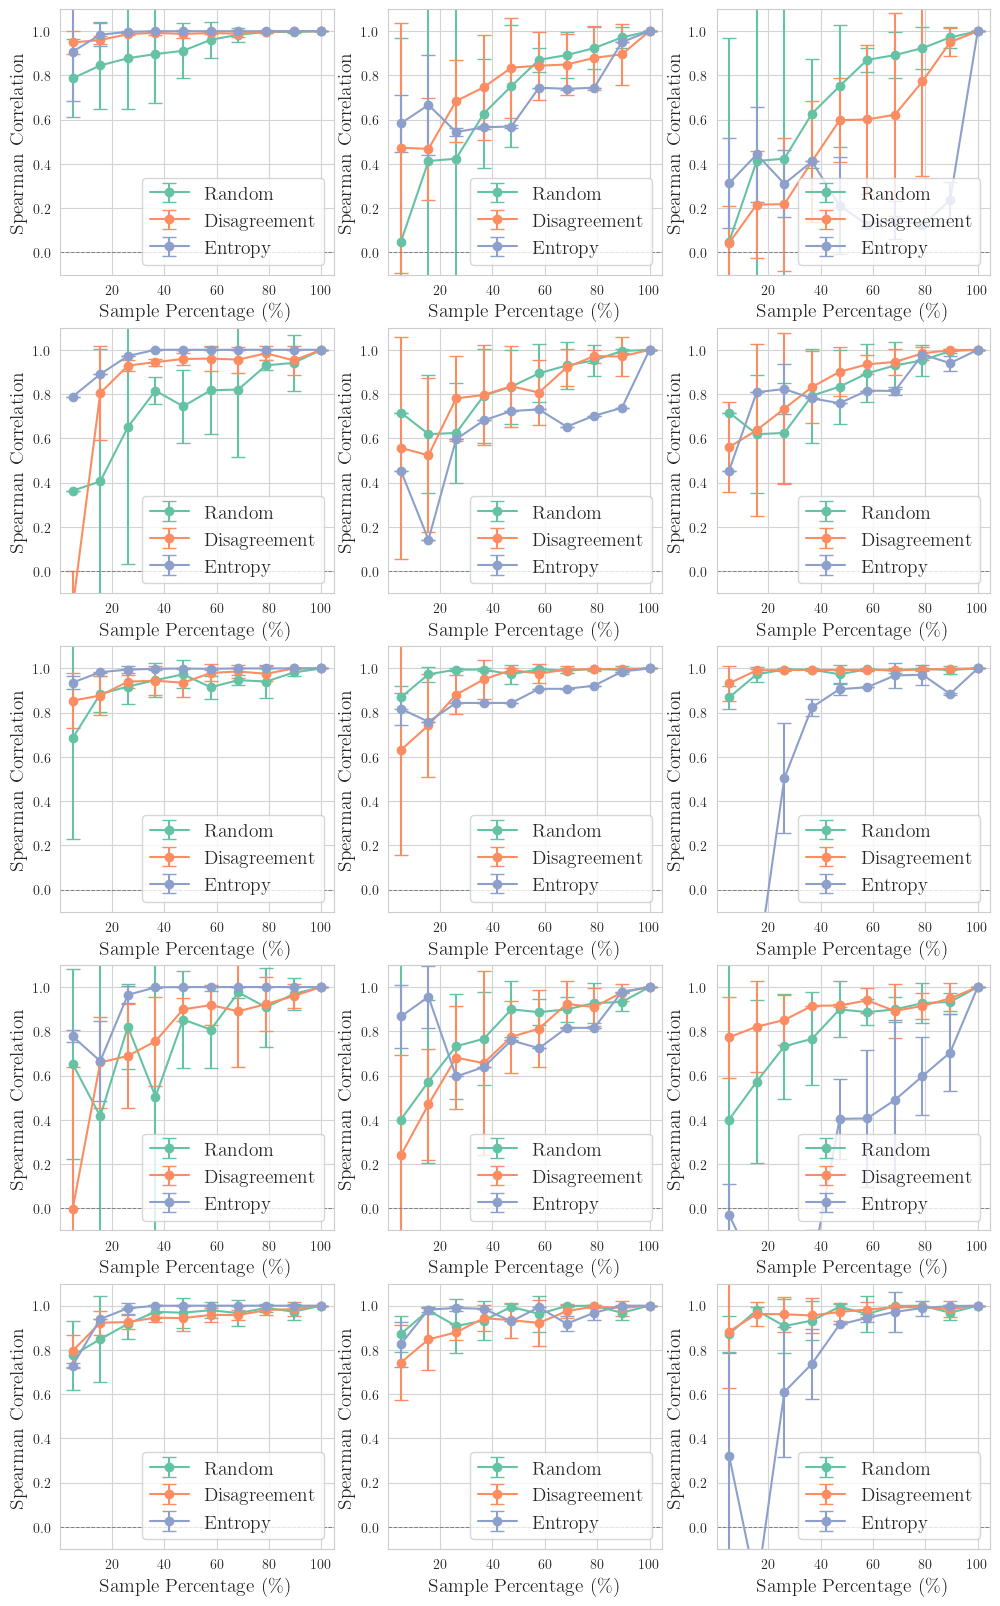

In [19]:
sp_results_acc, sp_results_len, sampled_ids, plot_data_df = plot_spearman_vs_sampling(performance_df, correctness_df, BENCHMARKS, ALL_GENOTYPES, ALL_GENOTYPES, SEED, k=4, sampling_methods={'random': get_random_sampled_indices, 'disagreement': get_disagreement_sampled_indices, 'entropy': get_entropy_sampled_indices})

In [13]:
plot_data_df.to_csv("sampling_spearman_data_1dot5B.csv", index=False)

In [14]:
sampled_ids_df = pd.DataFrame(sampled_ids)
sampled_ids_df.to_csv("sampled_ids_1dot5B.csv", index=False)

In [15]:
sampled_ids_df['sample_percent'].unique()

array([0.05      , 0.15555556, 0.26111111, 0.36666667, 0.47222222,
       0.57777778, 0.68333333, 0.78888889, 0.89444444, 1.        ])

In [16]:
len(sampled_ids_df[(sampled_ids_df['method'] == 'entropy') & (sampled_ids_df['benchmark'] == 'gsm8k') & (sampled_ids_df['sample_percent'] == 0.05) & (sampled_ids_df['score'] == 'accuracy') & (sampled_ids_df['fold'] == 0)]['sampled_ids'].values[0])

65

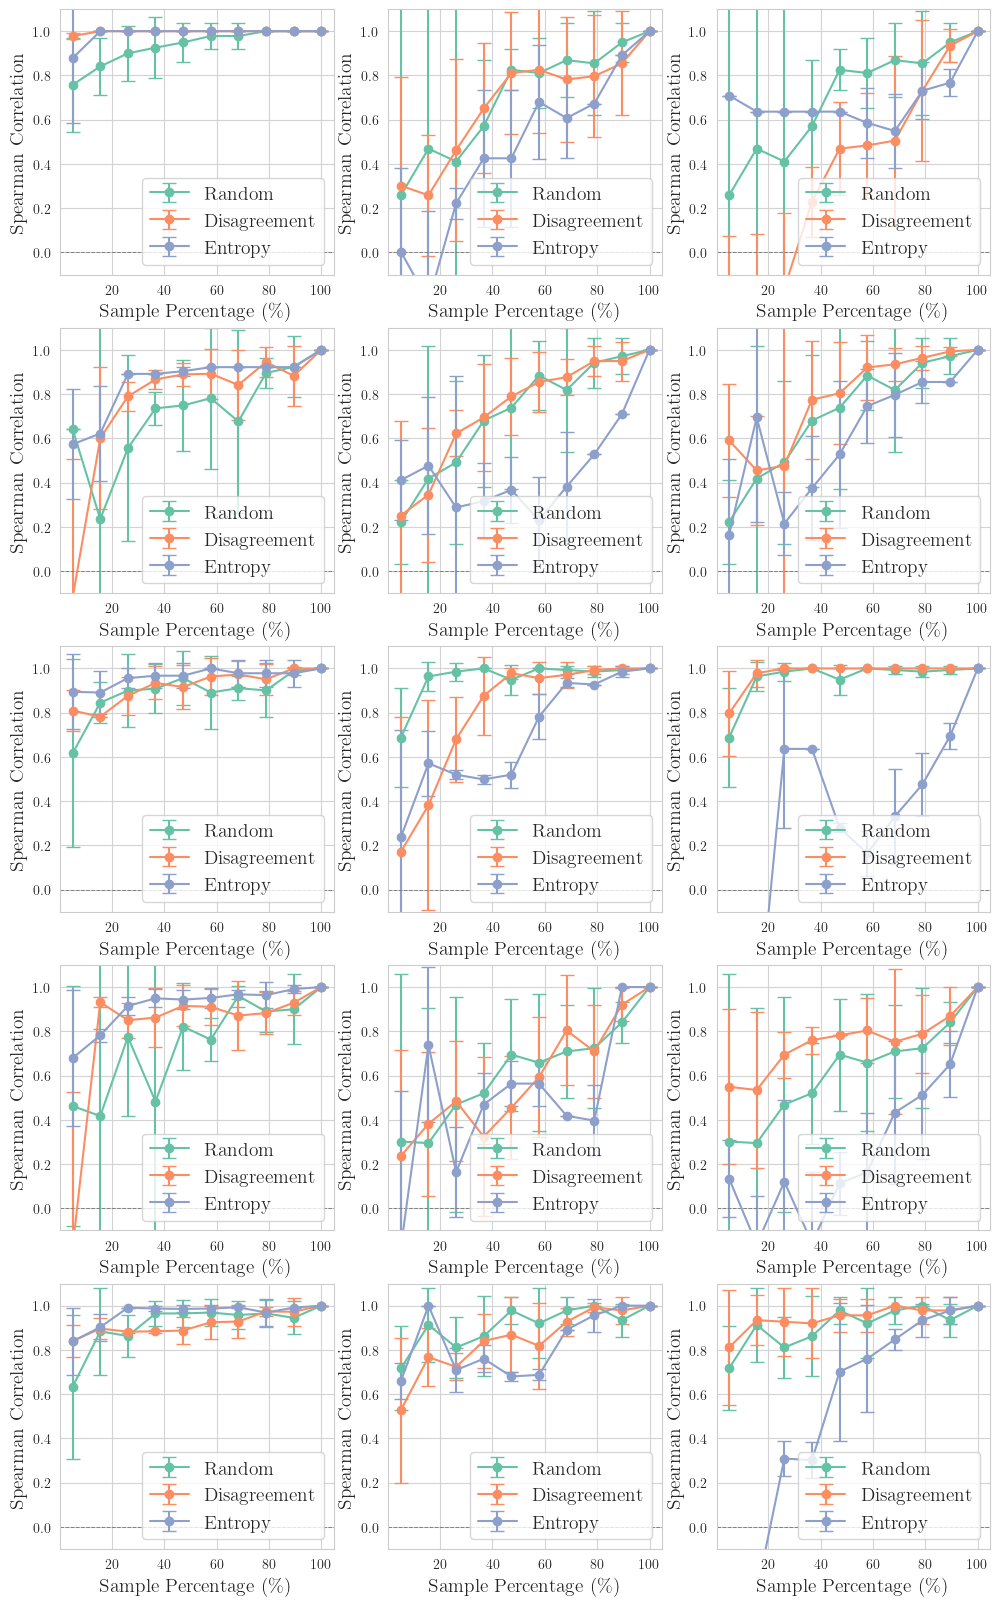

In [20]:
sp_results_acc, sp_results_len, sp_sampled_ids, sp_plot_data_df = plot_spearman_vs_sampling(performance_df, correctness_df, BENCHMARKS, GENOTYPES, VAL_GENOTYPES, SEED, k=5, sampling_methods={'random': get_random_sampled_indices, 'disagreement': get_disagreement_sampled_indices, 'entropy': get_entropy_sampled_indices})

In [21]:
# make markdown table for each benchmark
# put sampling methods as rows and sampling percentages as columns
for benchmark in BENCHMARKS:
    md_table = "| Sampling Method | " + " | ".join([f"{int(p*100)}%" for p in np.linspace(0.05, 1.0, 10)]) + " |\n"
    md_table += "|---" * (len(np.linspace(0.05, 1.0, 10)) + 1) + "|\n"
    for method in sp_results_acc:
        row = f"| {method} | " + " | ".join([f"{sp_results_acc[method][benchmark][i][0]:.3f} ± {sp_results_acc[method][benchmark][i][1]:.3f}" if not np.isnan(sp_results_acc[method][benchmark][i][0]) else "N/A" for i in range(len(sp_results_acc[method][benchmark]))]) + " |\n"
        md_table += row
    print(f"### Benchmark: {benchmark}\n")
    print(md_table)

### Benchmark: gsm8k

| Sampling Method | 5% | 15% | 26% | 36% | 47% | 57% | 68% | 78% | 89% | 100% |
|---|---|---|---|---|---|---|---|---|---|---|
| random | 0.757 ± 0.212 | 0.841 ± 0.129 | 0.900 ± 0.123 | 0.925 ± 0.137 | 0.949 ± 0.088 | 0.978 ± 0.061 | 0.978 ± 0.061 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 |
| disagreement | 0.978 ± 0.015 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 |
| entropy | 0.878 ± 0.295 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 |

### Benchmark: aime24

| Sampling Method | 5% | 15% | 26% | 36% | 47% | 57% | 68% | 78% | 89% | 100% |
|---|---|---|---|---|---|---|---|---|---|---|
| random | 0.642 ± 0.000 | 0.235 ± 0.954 | 0.555 ± 0.421 | 0.735 ± 0.074 | 0.749 ± 0.204 | 0.781 ± 0.318 | 0.676 ± 0.415 | 0.895 ± 0.068 | 0.923 ± 0.138 | 1.000 ± 0.000 |
| disagreem

## 1.5B

### Benchmark: aime24

| Sampling Method | 5% | 15% | 26% | 36% | 47% | 57% | 68% | 78% | 89% | 100% |
|---|---|---|---|---|---|---|---|---|---|---|
| random | N/A | 0.532 ± 0.757 | 0.660 ± 0.263 | 0.811 ± 0.235 | 0.846 ± 0.144 | 0.848 ± 0.083 | 0.890 ± 0.105 | 0.917 ± 0.095 | 0.970 ± 0.059 | 1.000 ± 0.000 |
| disagreement | 0.747 ± 0.098 | 0.772 ± 0.172 | 0.939 ± 0.010 | 0.945 ± 0.031 | 0.952 ± 0.032 | 0.960 ± 0.015 | 0.961 ± 0.014 | 0.970 ± 0.025 | 0.991 ± 0.024 | 1.000 ± 0.000 |
| entropy | 0.438 ± 0.582 | 0.868 ± 0.040 | 0.968 ± 0.010 | 0.991 ± 0.017 | 0.991 ± 0.017 | 0.996 ± 0.010 | 0.996 ± 0.010 | 0.996 ± 0.010 | 0.996 ± 0.010 | 1.000 ± 0.000 |

### Benchmark: gsm8k

| Sampling Method | 5% | 15% | 26% | 36% | 47% | 57% | 68% | 78% | 89% | 100% |
|---|---|---|---|---|---|---|---|---|---|---|
| random | 0.802 ± 0.126 | 0.827 ± 0.135 | 0.890 ± 0.126 | 0.926 ± 0.063 | 0.935 ± 0.097 | 0.981 ± 0.033 | 0.984 ± 0.026 | 0.994 ± 0.011 | 0.998 ± 0.004 | 1.000 ± 0.000 |
| disagreement | 0.913 ± 0.127 | 0.979 ± 0.040 | 0.989 ± 0.004 | 0.995 ± 0.004 | 0.994 ± 0.005 | 0.994 ± 0.004 | 0.978 ± 0.037 | 1.000 ± 0.001 | 0.999 ± 0.004 | 1.000 ± 0.000 |
| entropy | 0.881 ± 0.160 | 0.994 ± 0.013 | 0.994 ± 0.007 | 1.000 ± 0.000 | 1.000 ± 0.001 | 0.999 ± 0.004 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 |

### Benchmark: college_math

| Sampling Method | 5% | 15% | 26% | 36% | 47% | 57% | 68% | 78% | 89% | 100% |
|---|---|---|---|---|---|---|---|---|---|---|
| random | 0.686 ± 0.304 | 0.870 ± 0.104 | 0.927 ± 0.056 | 0.922 ± 0.081 | 0.964 ± 0.056 | 0.938 ± 0.054 | 0.946 ± 0.060 | 0.960 ± 0.045 | 0.990 ± 0.011 | 1.000 ± 0.000 |
| disagreement | 0.857 ± 0.073 | 0.875 ± 0.080 | 0.935 ± 0.028 | 0.959 ± 0.019 | 0.955 ± 0.049 | 0.985 ± 0.016 | 0.995 ± 0.006 | 0.965 ± 0.058 | 0.996 ± 0.006 | 1.000 ± 0.000 |
| entropy | 0.922 ± 0.032 | 0.928 ± 0.046 | 0.995 ± 0.006 | 0.997 ± 0.005 | 0.998 ± 0.004 | 0.997 ± 0.005 | 0.999 ± 0.004 | 1.000 ± 0.001 | 1.000 ± 0.000 | 1.000 ± 0.000 |

### Benchmark: minerva_math

| Sampling Method | 5% | 15% | 26% | 36% | 47% | 57% | 68% | 78% | 89% | 100% |
|---|---|---|---|---|---|---|---|---|---|---|
| random | 0.535 ± 0.438 | 0.681 ± 0.391 | 0.822 ± 0.097 | 0.596 ± 0.311 | 0.772 ± 0.332 | 0.750 ± 0.158 | 0.959 ± 0.026 | 0.926 ± 0.084 | 0.970 ± 0.050 | 1.000 ± 0.000 |
| disagreement | 0.024 ± 0.417 | 0.540 ± 0.388 | 0.683 ± 0.160 | 0.758 ± 0.140 | 0.903 ± 0.037 | 0.884 ± 0.070 | 0.943 ± 0.092 | 0.882 ± 0.118 | 0.978 ± 0.015 | 1.000 ± 0.000 |
| entropy | 0.839 ± 0.033 | 0.783 ± 0.144 | 0.958 ± 0.016 | 0.986 ± 0.011 | 0.998 ± 0.004 | 0.999 ± 0.003 | 0.999 ± 0.003 | 0.998 ± 0.003 | 0.999 ± 0.003 | 1.000 ± 0.000 |

### Benchmark: olympiadbench

| Sampling Method | 5% | 15% | 26% | 36% | 47% | 57% | 68% | 78% | 89% | 100% |
|---|---|---|---|---|---|---|---|---|---|---|
| random | 0.691 ± 0.283 | 0.859 ± 0.157 | 0.910 ± 0.083 | 0.954 ± 0.026 | 0.977 ± 0.029 | 0.967 ± 0.027 | 0.971 ± 0.029 | 0.997 ± 0.001 | 0.987 ± 0.024 | 1.000 ± 0.000 |
| disagreement | 0.797 ± 0.082 | 0.919 ± 0.053 | 0.922 ± 0.025 | 0.939 ± 0.021 | 0.947 ± 0.046 | 0.971 ± 0.021 | 0.974 ± 0.030 | 0.979 ± 0.023 | 0.995 ± 0.006 | 1.000 ± 0.000 |
| entropy | 0.740 ± 0.121 | 0.897 ± 0.065 | 0.993 ± 0.005 | 0.981 ± 0.019 | 0.999 ± 0.001 | 1.000 ± 0.000 | 1.000 ± 0.001 | 0.999 ± 0.001 | 0.999 ± 0.001 | 1.000 ± 0.000 |


## 7B 
### Benchmark: gsm8k

| Sampling Method | 5% | 15% | 26% | 36% | 47% | 57% | 68% | 78% | 89% | 100% |
|---|---|---|---|---|---|---|---|---|---|---|
| random | 0.835 ± 0.180 | 0.887 ± 0.196 | 0.940 ± 0.043 | 0.955 ± 0.048 | 0.977 ± 0.025 | 0.977 ± 0.025 | 0.971 ± 0.028 | 0.968 ± 0.022 | 0.975 ± 0.023 | 1.000 ± 0.000 |
| disagreement | 0.956 ± 0.037 | 0.991 ± 0.000 | 0.984 ± 0.020 | 0.989 ± 0.005 | 0.984 ± 0.022 | 0.984 ± 0.020 | 0.986 ± 0.015 | 0.978 ± 0.027 | 0.977 ± 0.025 | 1.000 ± 0.000 |
| entropy | 0.815 ± 0.260 | 0.907 ± 0.142 | 0.969 ± 0.037 | 0.991 ± 0.000 | 0.991 ± 0.000 | 0.991 ± 0.000 | 0.989 ± 0.009 | 0.991 ± 0.000 | 0.991 ± 0.000 | 1.000 ± 0.000 |